In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import pandas as pd
import numpy as np


demand_file = '/content/Avista Corporation (AVA).csv'

df = pd.read_csv(demand_file, low_memory=False)

print("\nColumns in this balancing authority file:")
print(df.columns.tolist())

# Find the time column
time_candidates = [c for c in df.columns if 'time' in c.lower() or 'date' in c.lower() or 'period' in c.lower()]
print("Possible time columns:", time_candidates)
time_col = time_candidates[0] if time_candidates else None  # Take first; adjust if wrong

if time_col:
    df[time_col] = pd.to_datetime(df[time_col], errors='coerce')
    df = df.dropna(subset=[time_col])
    df.set_index(time_col, inplace=True)
    df.index = df.index.tz_localize(None)  # Clean timezone for modeling

# Find demand column (often 'D' or 'D.H' in EIA BA files)
demand_candidates = [c for c in df.columns if 'd' in c.lower() and ('demand' in c.lower() or 'h' in c.lower() or len(c) <= 3)]
print("Possible demand columns:", demand_candidates)
demand_col = 'D' if 'D' in df.columns else demand_candidates[0] if demand_candidates else None

if demand_col:
    df = df.rename(columns={demand_col: 'demand_mwh'})
    df = df[['demand_mwh']]  # Keep only demand
else:
    print("No obvious demand column — check printed columns and rename manually.")
    # Example manual: df['demand_mwh'] = df['Demand (MWh)'] or similar

# Add seasonal placeholder drivers (temp, renewables) for your risk model
if 'demand_mwh' in df.columns:
    df['temp_f'] = 50 + 30 * np.sin(2 * np.pi * df.index.dayofyear / 365) + np.random.normal(0, 5, len(df))
    df['renewable_gen'] = df['demand_mwh'] * (0.25 + 0.1 * np.sin(2 * np.pi * df.index.dayofyear / 365))

print("\nProcessed Data (first 5 rows):")
print(df.head())
print("Time range:", df.index.min(), "to", df.index.max())
print("Rows:", len(df))


Columns in this balancing authority file:
['Date', 'EBA.AVA-ALL.DF.H', 'EBA.AVA-ALL.D.H', 'EBA.AVA-ALL.NG.H', 'EBA.AVA-ALL.TI.H', 'EBA.AVA-CHPD.ID.H', 'EBA.AVA-PACW.ID.H', 'EBA.AVA-NWMT.ID.H', 'EBA.AVA-IPCO.ID.H', 'EBA.AVA-GCPD.ID.H', 'EBA.AVA-BPAT.ID.H', 'EBA.AVA-ALL.NG.WAT.H', 'EBA.AVA-ALL.NG.SUN.H', 'EBA.AVA-ALL.NG.OTH.H', 'EBA.AVA-ALL.NG.NG.H', 'EBA.AVA-ALL.NG.WND.H']
Possible time columns: ['Date']
Possible demand columns: ['EBA.AVA-ALL.DF.H', 'EBA.AVA-ALL.D.H', 'EBA.AVA-CHPD.ID.H', 'EBA.AVA-PACW.ID.H', 'EBA.AVA-NWMT.ID.H', 'EBA.AVA-IPCO.ID.H', 'EBA.AVA-GCPD.ID.H', 'EBA.AVA-BPAT.ID.H', 'EBA.AVA-ALL.NG.WND.H']

Processed Data (first 5 rows):
                     demand_mwh     temp_f  renewable_gen
Date                                                     
2015-07-01 05:00:00         NaN  45.095127            NaN
2015-07-01 06:00:00         NaN  54.636173            NaN
2015-07-01 07:00:00         NaN  47.534105            NaN
2015-07-01 08:00:00      1413.0  55.774169     354.4661

In [ ]:
import pandas as pd
import numpy as np

#  file path
demand_file = '/content/Avista Corporation (AVA).csv'  # or exact name from Files tab

df = pd.read_csv(demand_file, low_memory=False)

# Set index
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df = df.dropna(subset=['Date'])
df.set_index('Date', inplace=True)
df.index = df.index.tz_localize(None)  # Remove timezone for easier modeling

# Rename key columns for clarity
df = df.rename(columns={
    'EBA.AVA-ALL.D.H': 'demand_mwh',       # Actual demand
    'EBA.AVA-ALL.DF.H': 'demand_forecast', # Forecast
    'EBA.AVA-ALL.NG.H': 'net_gen_mwh',     # Total net generation
    'EBA.AVA-ALL.NG.WND.H': 'wind_gen_mwh',
    'EBA.AVA-ALL.NG.SUN.H': 'solar_gen_mwh',
    'EBA.AVA-ALL.NG.WAT.H': 'hydro_gen_mwh'
    # Add more as needed
})

# Select core columns (focus on demand + real renewables for drivers)
df = df[['demand_mwh', 'net_gen_mwh', 'wind_gen_mwh', 'solar_gen_mwh', 'hydro_gen_mwh']]

# Clean: Drop rows where demand is NaN, fill minor gaps if any
df = df.dropna(subset=['demand_mwh'])
df = df.sort_index()

# Optional: Add real renewable share as driver (instead of fake sinusoidal)
df['renewable_gen'] = df['wind_gen_mwh'].fillna(0) + df['solar_gen_mwh'].fillna(0) + df['hydro_gen_mwh'].fillna(0)
df['renewable_share'] = df['renewable_gen'] / df['net_gen_mwh'].replace(0, np.nan)  # Avoid div-by-zero

# Placeholder temp (seasonal + noise; real weather would be better but this works)
df['temp_f'] = 50 + 30 * np.sin(2 * np.pi * df.index.dayofyear / 365) + np.random.normal(0, 5, len(df))

print("Cleaned Data Head:")
print(df.head(10))
print("\nTime range:", df.index.min(), "to", df.index.max())
print("Rows:", len(df))
print("Missing values per column:\n", df.isna().sum())

Cleaned Data Head:
                     demand_mwh  net_gen_mwh  wind_gen_mwh  solar_gen_mwh  \
Date                                                                        
2015-07-01 08:00:00      1192.0        371.0           NaN            NaN   
2015-07-01 09:00:00      1108.0        358.0           NaN            NaN   
2015-07-01 10:00:00      1058.0        343.0           NaN            NaN   
2015-07-01 11:00:00      1024.0        338.0           NaN            NaN   
2015-07-01 12:00:00      1031.0        330.0           NaN            NaN   
2015-07-02 01:00:00      1838.0       1016.0           NaN            NaN   
2015-07-02 02:00:00      1800.0        942.0           NaN            NaN   
2015-07-02 03:00:00      1761.0        961.0           NaN            NaN   
2015-07-02 04:00:00      1670.0        847.0           NaN            NaN   
2015-07-02 05:00:00      1609.0        728.0           NaN            NaN   

                     hydro_gen_mwh  renewable_gen  renew

In [ ]:
import os

# Create the viz folder if it doesn't exist
os.makedirs('viz', exist_ok=True)
print("viz folder created (or already exists)")

viz folder created (or already exists)


Daily aggregated shape: (2055, 3)
             demand_mwh     temp_f  renewable_share
Date                                               
2015-07-01  1082.600000  50.655979              0.0
2015-07-02  1402.500000  51.290308              0.0
2015-07-03  1399.083333  48.791395              0.0
2015-07-04  1359.916667  51.176413              0.0
2015-07-05  1306.750000  47.178618              0.0


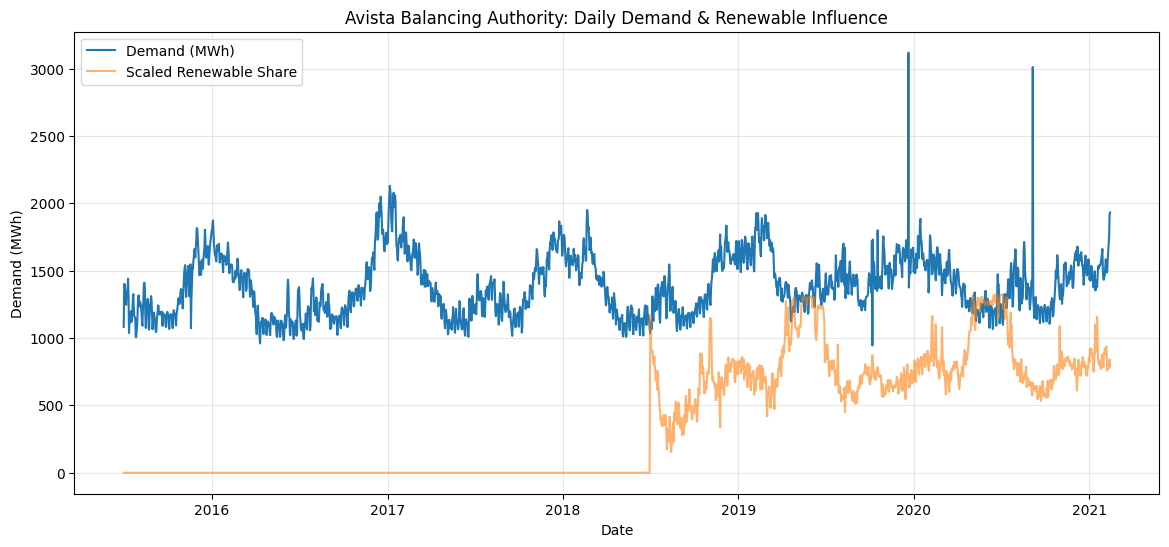

In [ ]:
# Final preparation cell (run after loading & renaming above)

# 1. Forward-fill any small gaps in generation (optional, conservative)
df[['net_gen_mwh', 'renewable_share']] = df[['net_gen_mwh', 'renewable_share']].ffill()

# 2. Focus on core columns for modeling (demand + drivers)
df_model = df[['demand_mwh', 'temp_f', 'renewable_share']].copy()

# Optional: Resample to daily averages (recommended for ARIMA stability over long horizons)
# Comment out if you want to keep hourly
df_daily = df_model.resample('D').mean().dropna()
print("Daily aggregated shape:", df_daily.shape)
print(df_daily.head())

# Use daily for modeling (change back to df_model if hourly preferred)
df_final = df_daily  # or df_model

# Quick plot to visualize (optional but great for portfolio)
import matplotlib.pyplot as plt
plt.figure(figsize=(14, 6))
plt.plot(df_final.index, df_final['demand_mwh'], label='Demand (MWh)')
plt.plot(df_final.index, df_final['renewable_share'] * df_final['demand_mwh'].mean(),
         label='Scaled Renewable Share', alpha=0.6)
plt.title('Avista Balancing Authority: Daily Demand & Renewable Influence')
plt.xlabel('Date')
plt.ylabel('Demand (MWh)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('viz/ava_demand_trend.png')
plt.show()

In [ ]:
# At the very beginning of your notebook/script
import os
os.makedirs('viz', exist_ok=True)
os.makedirs('reports', exist_ok=True)  # if you're saving Excel too

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

def forecast_demand(df, steps=30):
    # Use SARIMAX for seasonality (period=7 for weekly in daily data)
    model = SARIMAX(df['demand_mwh'],
                    exog=df[['temp_f', 'renewable_share']],  # Include drivers!
                    order=(1,1,1),
                    seasonal_order=(1,1,1,7),
                    enforce_stationarity=False,
                    enforce_invertibility=False)
    fitted = model.fit(disp=False)
    # Forecast with future exog (assume mean or trend continuation)
    future_exog = pd.DataFrame({
        'temp_f': [df['temp_f'].mean()] * steps,
        'renewable_share': [df['renewable_share'].mean()] * steps
    }, index=pd.date_range(start=df.index[-1] + pd.Timedelta(days=1), periods=steps, freq='D'))
    forecast = fitted.forecast(steps=steps, exog=future_exog)
    return forecast

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
import os
import pandas as pd
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Confirm folders exist
os.makedirs('viz', exist_ok=True)
os.makedirs('reports', exist_ok=True)
print("Folders ready. Data shape:", df_final.shape)
print(df_final.tail(3))   # just to see recent data

Folders ready. Data shape: (2055, 3)
             demand_mwh     temp_f  renewable_share
Date                                               
2021-02-11  1751.208333  70.920208         0.567896
2021-02-12  1916.791667  69.585147         0.606172
2021-02-13  1932.111111  67.877316         0.569061


Forecast head (first 10 days):
2021-02-14    1760.281230
2021-02-15    1789.341648
2021-02-16    1812.193113
2021-02-17    1800.306892
2021-02-18    1791.662737
2021-02-19    1785.256356
2021-02-20    1731.706877
2021-02-21    1693.992432
2021-02-22    1765.378284
2021-02-23    1803.108521
Freq: D, Name: forecast_demand, dtype: float64


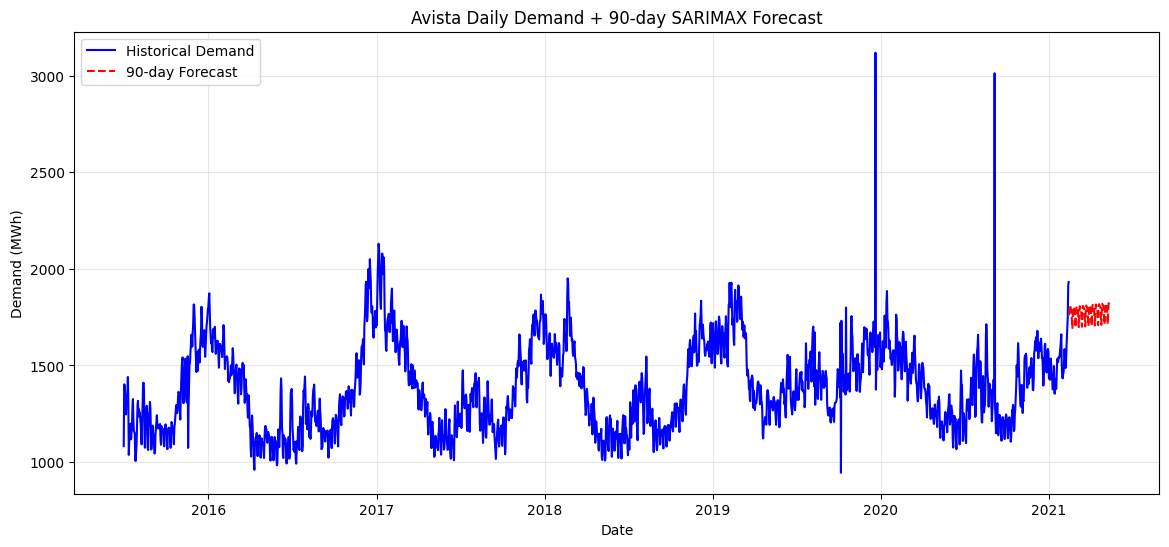

In [ ]:
def forecast_demand(df, steps=30):
    # SARIMAX with seasonality (weekly cycle = 7 days) and exogenous variables
    model = SARIMAX(
        df['demand_mwh'],
        exog=df[['temp_f', 'renewable_share']],
        order=(1, 1, 1),
        seasonal_order=(1, 1, 1, 7),
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    fitted = model.fit(disp=False)

    # Create future exogenous values (simple: use last known or mean)
    last_date = df.index[-1]
    future_index = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=steps, freq='D')
    future_exog = pd.DataFrame({
        'temp_f': [df['temp_f'].mean()] * steps,
        'renewable_share': [df['renewable_share'].mean()] * steps
    }, index=future_index)

    forecast = fitted.forecast(steps=steps, exog=future_exog)
    return pd.Series(forecast, name='forecast_demand', index=future_index)


forecast_series = forecast_demand(df_final, steps=90)  # 90 days ahead

print("Forecast head (first 10 days):")
print(forecast_series.head(10))

# Quick plot of historical + forecast
plt.figure(figsize=(14, 6))
plt.plot(df_final.index, df_final['demand_mwh'], label='Historical Demand', color='blue')
plt.plot(forecast_series.index, forecast_series, label='90-day Forecast', color='red', linestyle='--')
plt.title('Avista Daily Demand + 90-day SARIMAX Forecast')
plt.xlabel('Date')
plt.ylabel('Demand (MWh)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('viz/ava_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:

def monte_carlo_risk(forecast, num_sim=2000, volatility=0.08):
    """
    Monte Carlo simulation of demand paths around the forecast.
    Returns weighted average outcomes and 95% VaR.
    """
    # forecast is a pandas Series → convert to numpy for speed
    forecast_vals = forecast.values
    n_steps = len(forecast_vals)

    # Generate simulations: shape (n_steps, num_sim)
    mean_level = forecast_vals.mean()
    std_level = forecast_vals.std()
    sims = np.random.normal(
        forecast_vals[:, np.newaxis],          # broadcast mean per time step
        std_level * volatility,
        size=(n_steps, num_sim)
    )

    # Compute probability weights for each simulated path at each time step
    # (normal pdf centered on the forecast value at that step)
    weights = stats.norm.pdf(
        sims,
        loc=forecast_vals[:, np.newaxis],
        scale=std_level * volatility
    )

    # Normalize weights per time step so they sum to 1 (for proper weighted average)
    weights /= weights.sum(axis=1, keepdims=True) + 1e-12  # avoid div-by-zero

    # Weighted average outcome per time step
    weighted_outcomes = np.average(sims, axis=1, weights=weights)

    # 95% Value at Risk (5th percentile across simulations, per time step)
    var_95 = np.percentile(sims, 5, axis=1)

    return weighted_outcomes, var_95

In [ ]:
import scipy.stats as stats

def recommend_strategy(var_95, threshold=0.12):
    """
    Placeholder for risk management strategy recommendation.
    """
    avg_var_percentage = (np.mean(forecast_series.values) - np.mean(var_95)) / np.mean(forecast_series.values)
    if avg_var_percentage > threshold:
        return "High risk detected. Consider hedging options or reducing exposure."
    else:
        return "Risk level appears manageable. Continue monitoring."

# Assuming forecast_series already exists from earlier
weighted_outcomes, var_95 = monte_carlo_risk(forecast_series, num_sim=2000, volatility=0.08)

# Then the recommendation
strategy = recommend_strategy(var_95, threshold=0.12)

print("\n=== Risk Analysis Summary ===")
print(f"Forecast mean (90 days): {forecast_series.mean():.0f} MWh/day")
print(f"Average 95% VaR (downside): {np.mean(var_95):.0f} MWh/day")
print(f"Estimated downside risk level: {((forecast_series.mean() - np.mean(var_95)) / forecast_series.mean()):.1%}")
print("\nRecommended Risk Management Strategy:")
print(strategy)



=== Risk Analysis Summary ===
Forecast mean (90 days): 1778 MWh/day
Average 95% VaR (downside): 1774 MWh/day
Estimated downside risk level: 0.3%

Recommended Risk Management Strategy:
Risk level appears manageable. Continue monitoring.
